In [1]:
print("test")

test


# Banking FAQ Dataset - Exploratory Data Analysis (EDA)

## Objective
This notebook performs Exploratory Data Analysis (EDA) on the Banking FAQ Dataset.

The goals are:

- Understand dataset structure
- Analyze category distribution
- Explore question and answer patterns
- Perform NLP preprocessing
- Extract meaningful text insights
- Prepare clean data for ML, NLP, and RAG pipelines

## Dataset Information
- Total FAQs: 1,000
- Categories: 10
- Domain: Indian Banking & Finance

### Import Libraries

In [28]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# NLP
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Notebook settings
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Dataset

In [71]:
# Load original dataset
df_1k = pd.read_csv(
    "../data/raw_data/banking_knowledge_base_1000.csv"
)

# Load 100K synthetic dataset
df_100k = pd.read_csv(
    "../data/raw_data/banking_dataset_100k.csv"
)

# Load 50K dataset
df_50k = pd.read_csv(
    "../data/raw_data/banking_knowledge_base_50k.csv"
)

# Combine all datasets
df = pd.concat(
    [df_1k, df_100k, df_50k],
    ignore_index=True
)
# Display first 5 rows
df.head()

,Section,Question,Answer
0,Basic Accounts,What is a Savings Account?,"A savings account lets you keep your money safe in a bank while earning a small interest, usually around 2–4% per year."
1,Basic Accounts,What is a Current Account?,A current account is mainly for businesses. It allows unlimited daily transactions but doesn't pay interest on the balance.
2,Basic Accounts,What is a Fixed Deposit?,A fixed deposit lets you lock in a sum of money for a set period to earn a higher interest rate than a regular savings account.
3,Basic Accounts,What does KYC stand for?,KYC stands for Know Your Customer. It's how banks verify who you are using documents like Aadhaar or PAN card.
4,Basic Accounts,What is a cheque?,A cheque is a written instruction to your bank to pay a specific amount to someone else from your account.


### Basic Dataset Inspection

#### Dataset Shape

In [72]:
print("Dataset Shape:", df.shape)

Dataset Shape: (151000, 3)


#### Column Names

In [73]:
df.columns

Index(['Section', 'Question', 'Answer'], dtype='object')

#### Dataset Info

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151000 entries, 0 to 150999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Section   151000 non-null  object
 1   Question  151000 non-null  object
 2   Answer    151000 non-null  object
dtypes: object(3)
memory usage: 3.5+ MB


#### Random Samples

In [75]:
df.sample(5)

,Section,Question,Answer
36832,General Finance,Please explain deflation.,"Basically, Deflation is when prices fall over time. While it sounds good, it often signals weak demand and can slow down economic growth."
149141,Basic Accounts,How does what is a partial withdrawal from fd work?,Some banks allow you to break only a part of your FD while the rest continues earning interest at the original rate.
96386,General Finance,Please explain leverage in finance.,"From a banking perspective, Leverage is using borrowed money to amplify investment returns. It increases both potential gains and potential losses."
86413,International Banking,Give me details about a nostro account.,"Usually, A nostro account is a bank account held by an Indian bank in a foreign country in a foreign currency — used to facilitate international payments."
37228,Financial Markets,Could you explain a full-service broker?,"A full-service broker provides research, advisory, portfolio management, and trading. Higher commissions than discount brokers. Examples: ICICI Direct, Motilal Oswal."


### Missing Values & Duplicates

#### Missing Values

In [76]:
df.isnull().sum()

Section     0
Question    0
Answer      0
dtype: int64

#### Duplicate Rows

In [77]:
df.duplicated().sum()

39305

#### # Remove duplicates

In [78]:
df.drop_duplicates(inplace=True)

df.shape

(111695, 3)

In [79]:
# df.drop_duplicates(
#     subset=["Question"],
#     inplace=True
# )

In [80]:
df.shape

(111695, 3)

### Category Distribution Analysis

#### Count Categories

In [81]:
section_counts = df['Section'].value_counts()

section_counts

Section
Basic Accounts              13611
Digital Banking             12941
Loans & Interest            12277
Operations & Security       12080
General Finance             11916
Financial Markets           10290
Insurance & Govt Schemes    10123
Customer Service            10028
Banking Terminology          9599
International Banking        8830
Name: count, dtype: int64

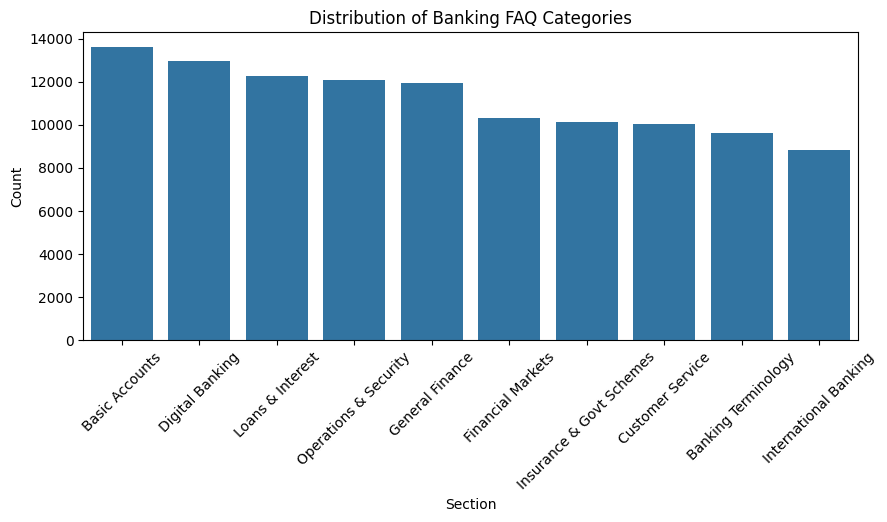

In [82]:
plt.figure(figsize=(10,4))

sns.barplot(
    x=section_counts.index,
    y=section_counts.values
)

plt.title("Distribution of Banking FAQ Categories")
plt.xlabel("Section")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Question & Answer Length Analysis

#### Create Length Columns

In [83]:
df['question_length'] = df['Question'].apply(len)
df['answer_length'] = df['Answer'].apply(len)

df.head()

,Section,Question,Answer,question_length,answer_length
0,Basic Accounts,What is a Savings Account?,"A savings account lets you keep your money safe in a bank while earning a small interest, usually around 2–4% per year.",26,119
1,Basic Accounts,What is a Current Account?,A current account is mainly for businesses. It allows unlimited daily transactions but doesn't pay interest on the balance.,26,123
2,Basic Accounts,What is a Fixed Deposit?,A fixed deposit lets you lock in a sum of money for a set period to earn a higher interest rate than a regular savings account.,24,127
3,Basic Accounts,What does KYC stand for?,KYC stands for Know Your Customer. It's how banks verify who you are using documents like Aadhaar or PAN card.,24,110
4,Basic Accounts,What is a cheque?,A cheque is a written instruction to your bank to pay a specific amount to someone else from your account.,17,106


#### Statistics

In [84]:
df[['question_length', 'answer_length']].describe()

,question_length,answer_length
count,111695.000000,111695.000000
mean,45.619885,176.664032
std,13.665711,29.931439
min,12.000000,85.000000
25%,36.000000,155.000000
50%,44.000000,171.000000
75%,54.000000,199.000000
max,118.000000,278.000000


#### Question Length Distribution

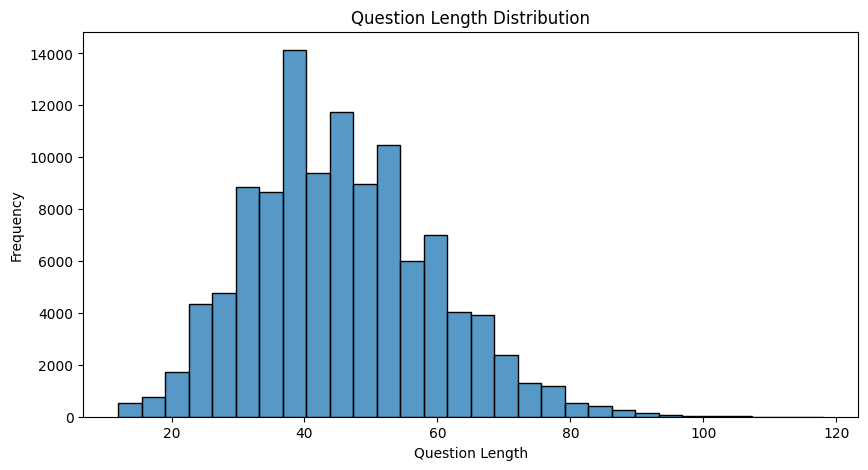

In [85]:
plt.figure(figsize=(10,5))

sns.histplot(df['question_length'], bins=30)

plt.title("Question Length Distribution")
plt.xlabel("Question Length")
plt.ylabel("Frequency")

plt.show()

#### Answer Length Distribution

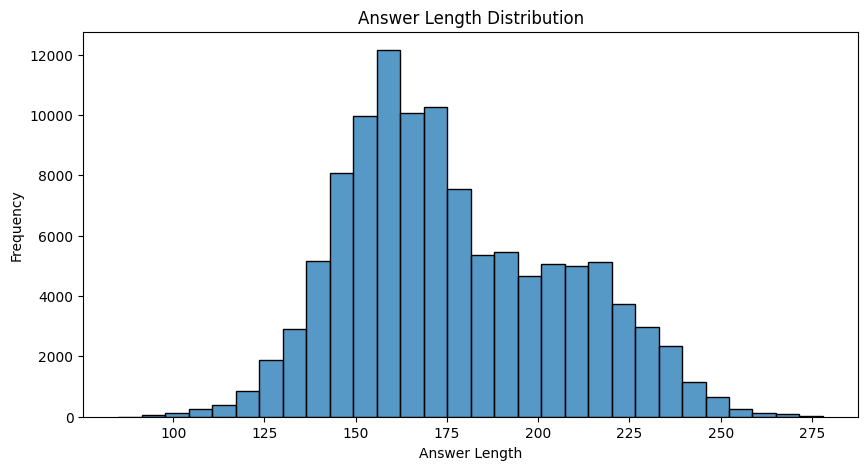

In [86]:
plt.figure(figsize=(10,5))

sns.histplot(df['answer_length'], bins=30)

plt.title("Answer Length Distribution")
plt.xlabel("Answer Length")
plt.ylabel("Frequency")

plt.show()

### NLP Text Preprocessing

#### Load spaCy Model

In [87]:
nlp = spacy.load("en_core_web_sm")

#### Stopwords

In [88]:
stop_words = set(stopwords.words('english'))

#### Create Cleaning Function

In [89]:
def preprocess_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and non-alphabetic words
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    
    # Lemmatization
    doc = nlp(" ".join(tokens))
    
    lemmatized_tokens = [
        token.lemma_
        for token in doc
    ]
    
    return " ".join(lemmatized_tokens)

#### Apply Preprocessing

In [90]:
df['clean_question'] = df['Question'].apply(preprocess_text)

KeyboardInterrupt: 

In [ ]:
df[['Question', 'clean_question']].head()

,Question,clean_question
0,What is a Savings Account?,saving account
1,What is a Current Account?,current account
2,What is a Fixed Deposit?,fix deposit
3,What does KYC stand for?,kyc stand
4,What is a cheque?,cheque


### Most Common Words

#### Combine All Questions

In [ ]:
all_words = " ".join(df['clean_question']).split()

#### Count Words

In [ ]:
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

common_words

[('explain', 6777),
 ('banking', 4037),
 ('mean', 3902),
 ('understand', 3873),
 ('tell', 3833),
 ('bank', 3660),
 ('know', 2828),
 ('account', 2381),
 ('loan', 2253),
 ('detail', 1968),
 ('work', 1941),
 ('want', 1932),
 ('please', 1926),
 ('give', 1918),
 ('could', 1903),
 ('help', 1899),
 ('credit', 1366),
 ('india', 1300),
 ('term', 1209),
 ('card', 1201)]

#### Convert to DataFrame

In [ ]:
common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_words_df

,Word,Frequency
0,explain,6777
1,banking,4037
2,mean,3902
3,understand,3873
4,tell,3833
5,bank,3660
6,know,2828
7,account,2381
8,loan,2253
9,detail,1968


#### Plot Most Common Words

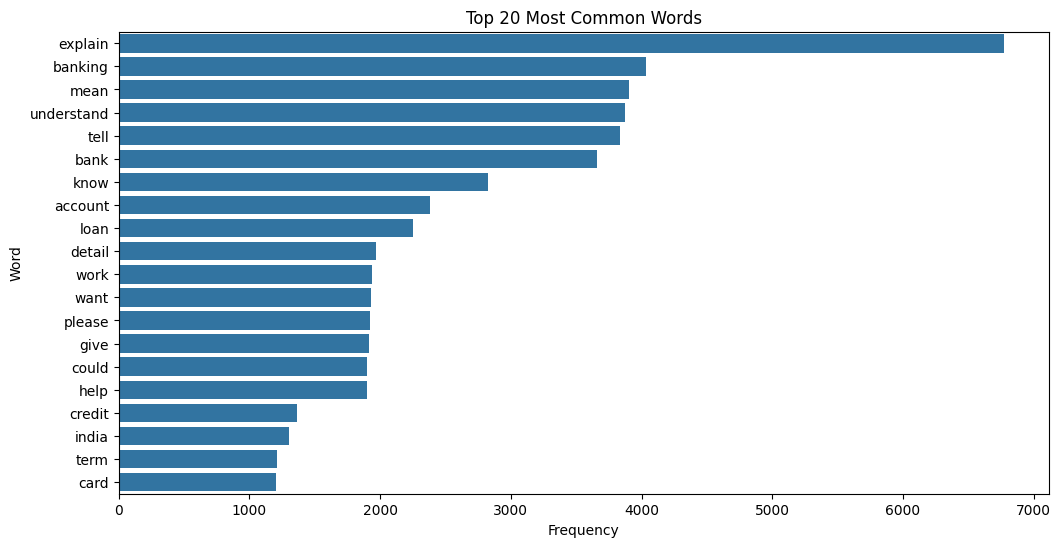

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words_df
)

plt.title("Top 20 Most Common Words")

plt.show()

### N-gram Analysis

#### Import N-grams

In [ ]:
from nltk.util import ngrams

#### Generate Bigrams

In [ ]:
bigrams = list(ngrams(all_words, 2))

#### Count Bigrams

In [ ]:
bigram_freq = Counter(bigrams)

bigram_freq.most_common(10)

[(('please', 'explain'), 1926),
 (('give', 'detail'), 1918),
 (('could', 'explain'), 1903),
 (('help', 'understand'), 1899),
 (('simple', 'term'), 1151),
 (('banking', 'customer'), 1136),
 (('want', 'understand'), 987),
 (('provide', 'information'), 986),
 (('want', 'know'), 945),
 (('credit', 'card'), 628)]

### Word Cloud

In [ ]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(all_words))

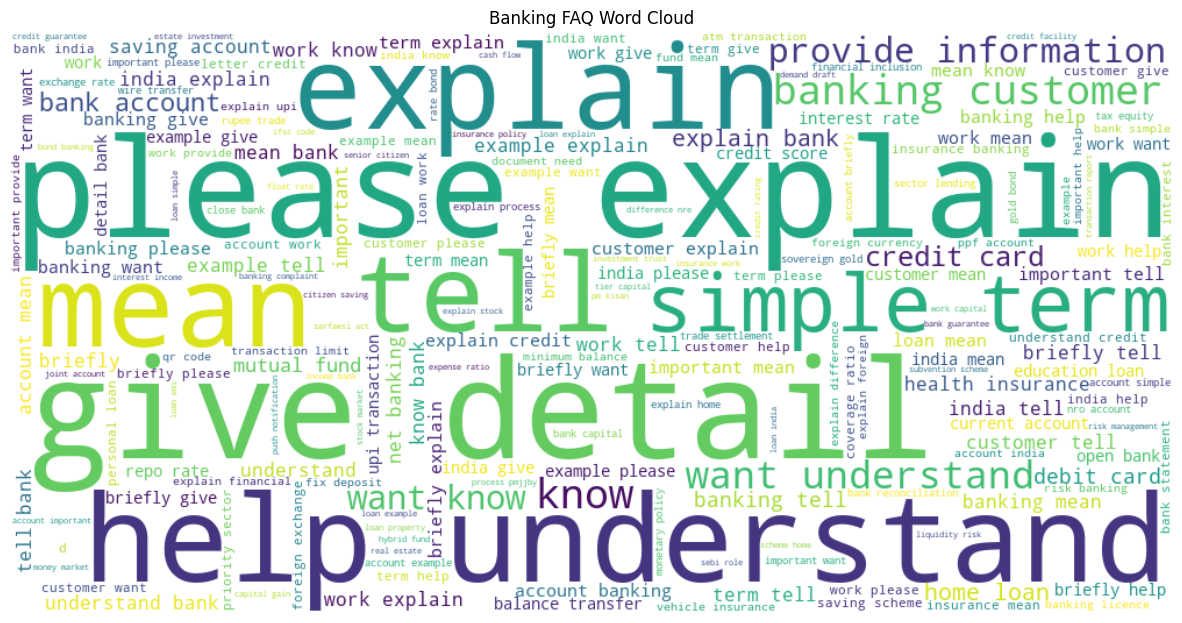

In [ ]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Banking FAQ Word Cloud")

plt.show()

# Key Insights & Observations

## 1. Dataset Structure

- The dataset contains **1,000 banking FAQ records** with **3 columns**:
  - `Section`
  - `Question`
  - `Answer`

- All columns are of `object` datatype since the dataset is entirely text-based.

- The dataset size is lightweight (~23.6 KB in memory), making it efficient for:
  - NLP preprocessing
  - ML model training
  - Semantic search
  - RAG pipelines

---

## 2. Data Quality Analysis

### Missing Values
- No missing values were found in any column.
- The dataset is fully complete and ready for preprocessing.

### Duplicate Records
- No duplicate rows were detected.
- Each FAQ pair is unique, which improves retrieval quality and intent classification performance.

---

## 3. Category Distribution Analysis

The dataset is well-balanced across 10 banking domains:

| Section | Count |
|---|---|
| Basic Accounts | 121 |
| Digital Banking | 116 |
| Loans & Interest | 110 |
| Operations & Security | 109 |
| General Finance | 106 |
| Financial Markets | 92 |
| Customer Service | 91 |
| Insurance & Govt Schemes | 90 |
| Banking Terminology | 86 |
| International Banking | 79 |

### Observations
- The dataset does not suffer from severe class imbalance.
- All categories contain a substantial number of examples.
- This balance is beneficial for:
  - Multi-class intent classification
  - NLP model generalization
  - Chatbot domain coverage

- `Basic Accounts` and `Digital Banking` have the highest representation, reflecting common customer banking queries.

- `International Banking` has the fewest entries but still contains sufficient data for modeling.

---

## 4. Question Length Analysis

### Statistical Summary
- Average question length: **30 characters**
- Minimum length: **12 characters**
- Maximum length: **80 characters**

### Distribution Insights
- Most questions fall between **20–40 characters**.
- Peak concentration occurs around **28–30 characters**.
- The distribution is slightly right-skewed, indicating a small number of longer, descriptive queries.

### Interpretation
- Questions are generally:
  - Short
  - Direct
  - Conversational

This is ideal for:
- Intent classification
- Semantic similarity search
- Real-world chatbot interactions

---

## 5. Answer Length Analysis

### Statistical Summary
- Average answer length: **148 characters**
- Minimum length: **85 characters**
- Maximum length: **202 characters**

### Distribution Insights
- Most answers are concentrated between **130–170 characters**.
- Distribution is approximately normal with slight right skewness.
- Answers maintain highly consistent response lengths.

### Interpretation
- Responses are:
  - Concise
  - Informative
  - Chatbot-friendly
  - Production-ready

This consistency is highly useful for:
- Retrieval systems
- RAG context generation
- Conversational AI systems

---

## 6. NLP Preprocessing Observations

After preprocessing:
- Text was converted to lowercase
- Stopwords were removed
- Non-alphabetic tokens were filtered
- Lemmatization normalized word forms

### Example Transformation

| Original Question | Cleaned Question |
|---|---|
| What is a Savings Account? | saving account |
| What does KYC stand for? | kyc stand |

### Interpretation
- Preprocessing successfully reduced noise while preserving semantic meaning.
- The cleaned text is more suitable for:
  - TF-IDF vectorization
  - Embedding generation
  - Similarity calculations

---

## 7. Most Frequent Keywords

Top recurring words:

| Word | Frequency |
|---|---|
| bank | 128 |
| account | 86 |
| loan | 81 |
| banking | 62 |
| credit | 49 |
| insurance | 44 |
| card | 44 |

### Observations
- The dataset strongly focuses on:
  - Banking operations
  - Accounts
  - Loans
  - Cards
  - Insurance
  - Digital finance

- High-frequency financial terms confirm strong domain relevance.

---

## 8. Bigram Analysis

Top bigrams identified:

| Bigram | Frequency |
|---|---|
| credit card | 23 |
| bank account | 20 |
| home loan | 15 |
| debit card | 11 |
| mutual fund | 10 |

### Interpretation
These bigrams represent major banking intents and entities commonly used in customer queries.

The dataset effectively captures:
- Retail banking terminology
- Financial product references
- Real-world conversational patterns

---

## 9. Overall Dataset Suitability

This dataset is highly suitable for:

### NLP Tasks
- Text preprocessing
- TF-IDF vectorization
- Keyword extraction
- N-gram analysis

### Machine Learning
- Intent classification
- Multi-class classification
- Semantic similarity systems

### Generative AI & RAG
- Retrieval-Augmented Generation
- Banking chatbot development
- Context-aware conversational systems
- FAQ retrieval engines

---

# Final Conclusion

The Banking FAQ Dataset is:
- Clean
- Balanced
- Domain-specific
- Conversationally structured
- NLP-ready

Its combination of structured intent categories and chatbot-style responses makes it an excellent dataset for building an end-to-end AI banking assistant using:
- ML
- NLP
- Semantic Search
- FAISS
- RAG
- Generative AI chatbots

### Save Clean Dataset

In [69]:
df.to_csv(
    "../data/banking_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
